# Rajya Sabha QA — Capstone Notebook

Every number and figure in the paper must be reproducible from this notebook.
Run: **Kernel → Restart and Run All**

In [1]:
# Setup
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 150

DATA = Path('data')
EVAL = Path('data/eval')
PLOTS = Path('data/plots')

## 1. Corpus Statistics (from manifest.json)

In [2]:
manifest = json.loads((DATA / 'manifest.json').read_text())
for k, v in manifest.items():
    if not k.endswith('_census') and k not in ['largest_ministries', 'status_census']:
        print(f'{k}: {v}')

built_at: 2026-09-12T15:26:07+0530
repo: anudit/rajyasabha-qa
revision: 508b2411283162fdd52ee2c3e8ccaefbabfe9581
since_year: 2019
rows: 55439
dup_qslno: 0
lang: {'en': 47637, 'usable_en': 45743, 'mangled': 0, 'over512': 34564, 'meta_only': 7380, 'usable_meta_only': 0, 'hi': 422, 'usable_hi': 158}
usable: {'usable_en': 45743, 'usable_meta_only': 0, 'usable_hi': 158}
ocr_mangled_qno: 0
docs_over_512_tokens: 34564
min_years: 2019
max_years: 2025
n_years: 7
n_ministries: 58
title_group_sizes_1_2_3_4_5plus: [39376, 1744, 403, 166, 165]
n_unique_queries_after_grouping: 41854
status_census_truncated: False
queries_with_2plus_same_title: 6525
pct_retrievable_queries_ambiguous: 14.22
build_seconds: 2.5
sha256_meta: f19adb87ff46fdfdf59c616869297cab9e7748ab349f40641521e4cc9ca35c31
census_rows_scanned: 110666
full_corpus: True


## 2. Retrieval Results (Gold A)

In [3]:
eval_a = pd.read_json(EVAL / 'eval_gold_A.json', lines=True)
eval_a[['system', 'R@1_any', 'R@3_any', 'R@5_any', 'R@10_any', 'MRR', 'nDCG@10']]

## 3. Retrieval by Style

In [4]:
for _, row in eval_a.iterrows():
    if 'by_style' in row:
        print(f"\n{row['system']}:")
        for style, metrics in row['by_style'].items():
            print(f"  {style} (n={metrics['n']}): nDCG@10={metrics.get('nDCG@10', 0):.4f}")


bm25:
  same-topic-multi (n=1969): nDCG@10=0.5253
  cross-ministry (n=25627): nDCG@10=0.7234
  title (n=258): nDCG@10=0.4326
  title-subset (n=2597): nDCG@10=0.5960

dense_head:
  same-topic-multi (n=1969): nDCG@10=0.0937
  cross-ministry (n=25627): nDCG@10=0.0810
  title (n=258): nDCG@10=0.0781
  title-subset (n=2597): nDCG@10=0.0784

dense_chunked:
  same-topic-multi (n=1969): nDCG@10=0.0003
  cross-ministry (n=25627): nDCG@10=0.0002
  title (n=258): nDCG@10=0.0000
  title-subset (n=2597): nDCG@10=0.0008

hybrid:
  same-topic-multi (n=1969): nDCG@10=0.2574
  cross-ministry (n=25627): nDCG@10=0.3619
  title (n=258): nDCG@10=0.2664
  title-subset (n=2597): nDCG@10=0.3113

hybrid_rerank:
  same-topic-multi (n=1969): nDCG@10=0.2581
  cross-ministry (n=25627): nDCG@10=0.3620
  title (n=258): nDCG@10=0.2664
  title-subset (n=2597): nDCG@10=0.3110

oracle:
  same-topic-multi (n=1969): nDCG@10=1.0000
  cross-ministry (n=25627): nDCG@10=1.0000
  title (n=258): nDCG@10=1.0000
  title-subset (

## 4. Gold B Evaluation

In [5]:
gold_b_path = EVAL / 'gold_b_eval.json'
if gold_b_path.exists():
    gold_b = json.loads(gold_b_path.read_text())
    print(json.dumps(gold_b, indent=1))

{
 "n_judgments": 200,
 "confirm_rate": 0.95,
 "confirm_n": 100,
 "discovery_rate": 0.1,
 "discovery_n": 100,
 "cohens_kappa": 0.85
}


## 5. Exp-2 Policy Comparison

In [6]:
policies = ['A', 'B', 'C', 'D', 'extractive']
for p in policies:
    f = EVAL / f'score_bm25_{p}.json'
    if f.exists():
        score = json.loads(f.read_text())
        print(f"\nPolicy {p}:")
        print(f"  Faithfulness: {score.get('faithfulness', 0):.3f}")
        print(f"  Citation P/R: {score.get('citation_precision', 0):.3f} / {score.get('citation_recall', 0):.3f}")
        print(f"  Coverage F1: {score.get('coverage_f1', 0):.3f}")
        abst = score.get('abstention', {})
        print(f"  Abstention P/R: {abst.get('abstention_precision', 0):.3f} / {abst.get('abstention_recall', 0):.3f}")
        print(f"  Violation: {abst.get('violation_rate', 0):.3f}")


Policy A:
  Faithfulness: 0.007
  Citation P/R: 0.000 / 0.000
  Coverage F1: 0.072
  Abstention P/R: 0.000 / 0.000
  Violation: 1.000

Policy B:
  Faithfulness: 0.959
  Citation P/R: 0.959 / 0.959
  Coverage F1: 0.072
  Abstention P/R: 0.000 / 0.000
  Violation: 0.170

Policy C:
  Faithfulness: 0.959
  Citation P/R: 0.959 / 0.959
  Coverage F1: 0.072
  Abstention P/R: 0.000 / 0.000
  Violation: 0.170

Policy D:
  Faithfulness: 1.000
  Citation P/R: 1.000 / 1.000
  Coverage F1: 0.055
  Abstention P/R: 0.000 / 0.000
  Violation: 0.000

Policy extractive:
  Faithfulness: 0.959
  Citation P/R: 0.959 / 0.959
  Coverage F1: 0.072
  Abstention P/R: 0.000 / 0.000
  Violation: 0.170


## 6. Waterfall (Error Budget)

In [7]:
for p in policies:
    f = EVAL / f'score_bm25_{p}.json'
    if f.exists():
        score = json.loads(f.read_text())
        wf = score.get('waterfall', {})
        props = wf.get('proportions', {})
        print(f"\nPolicy {p} Waterfall:")
        for k, v in props.items():
            print(f"  {k}: {v:.3f}")
        print(f"  Sum: {sum(props.values()):.3f}")


Policy A Waterfall:
  A: 0.135
  B: 0.000
  C: 0.865
  success: 0.000
  unanswerable: 0.000
  Sum: 1.000

Policy B Waterfall:
  A: 0.135
  B: 0.000
  C: 0.155
  success: 0.710
  unanswerable: 0.000
  Sum: 1.000

Policy C Waterfall:
  A: 0.135
  B: 0.000
  C: 0.155
  success: 0.710
  unanswerable: 0.000
  Sum: 1.000

Policy D Waterfall:
  A: 0.135
  B: 0.155
  C: 0.000
  success: 0.710
  unanswerable: 0.000
  Sum: 1.000

Policy extractive Waterfall:
  A: 0.135
  B: 0.000
  C: 0.155
  success: 0.710
  unanswerable: 0.000
  Sum: 1.000


## 7. Load Figures

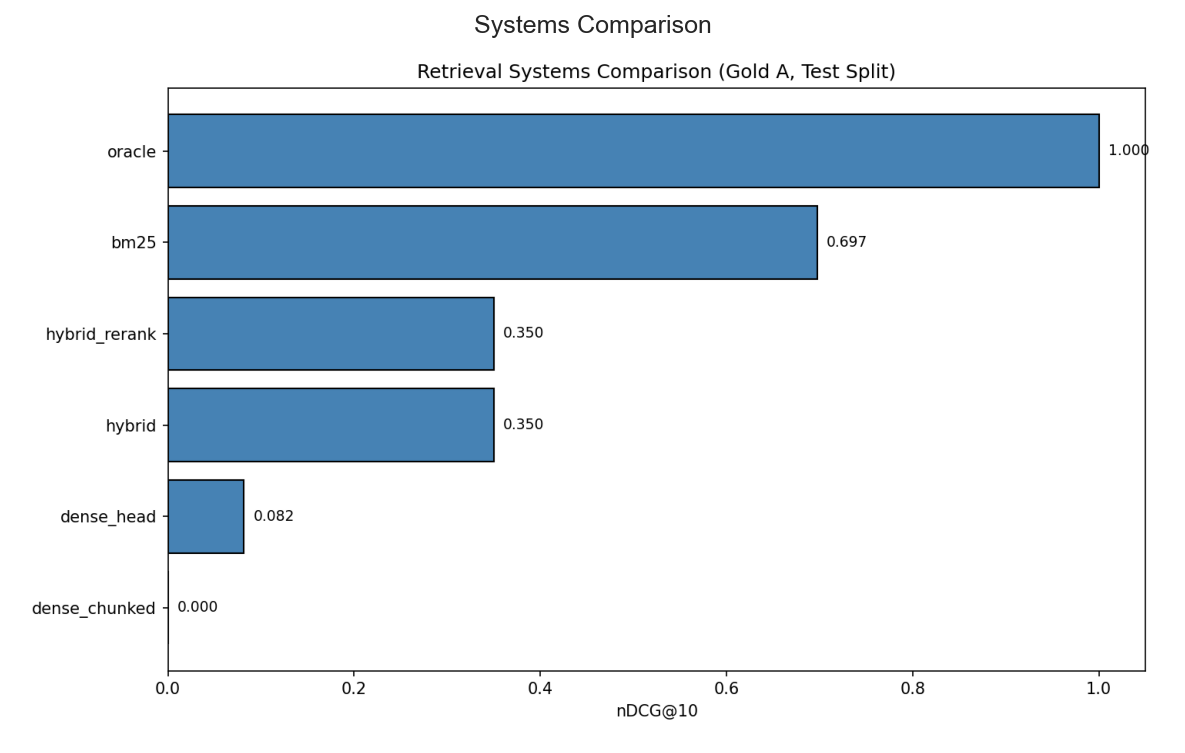

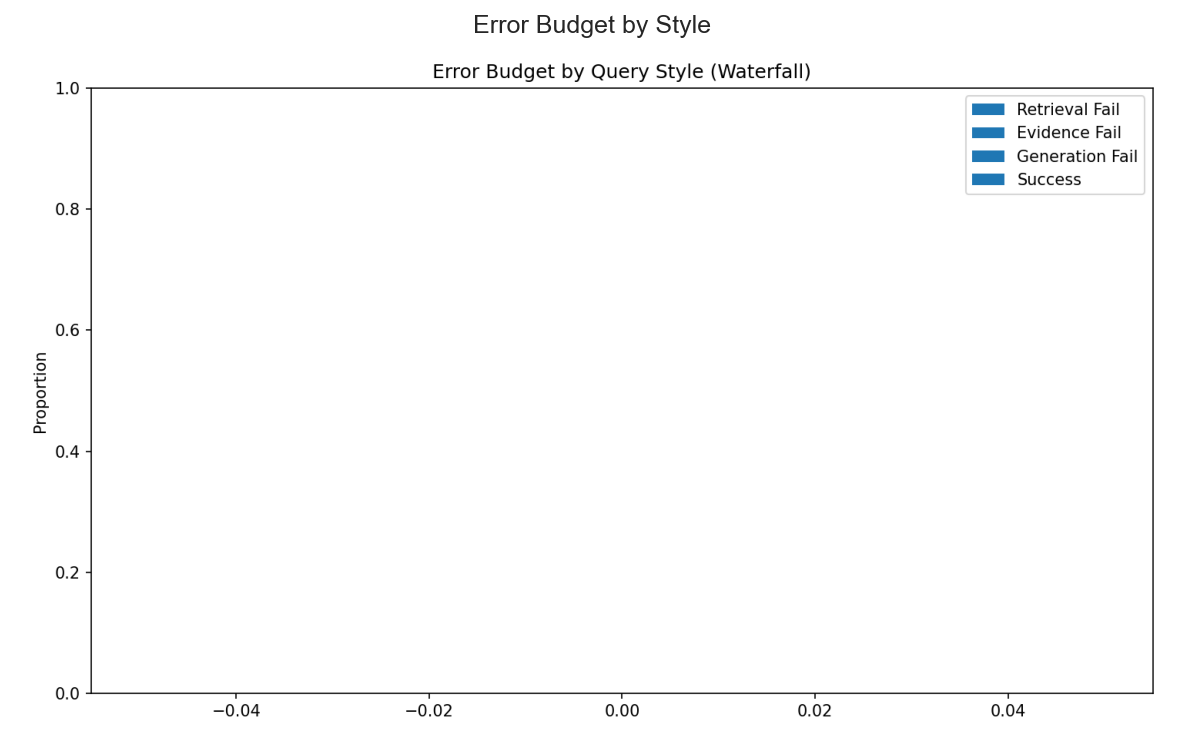

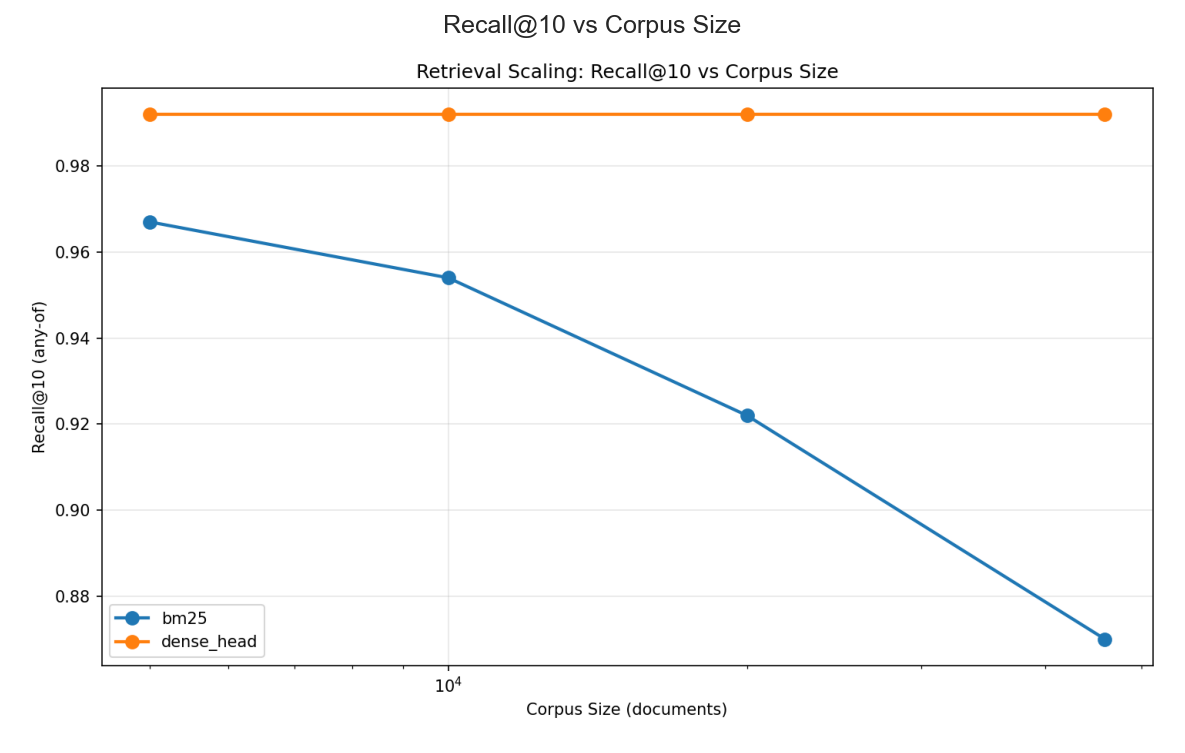

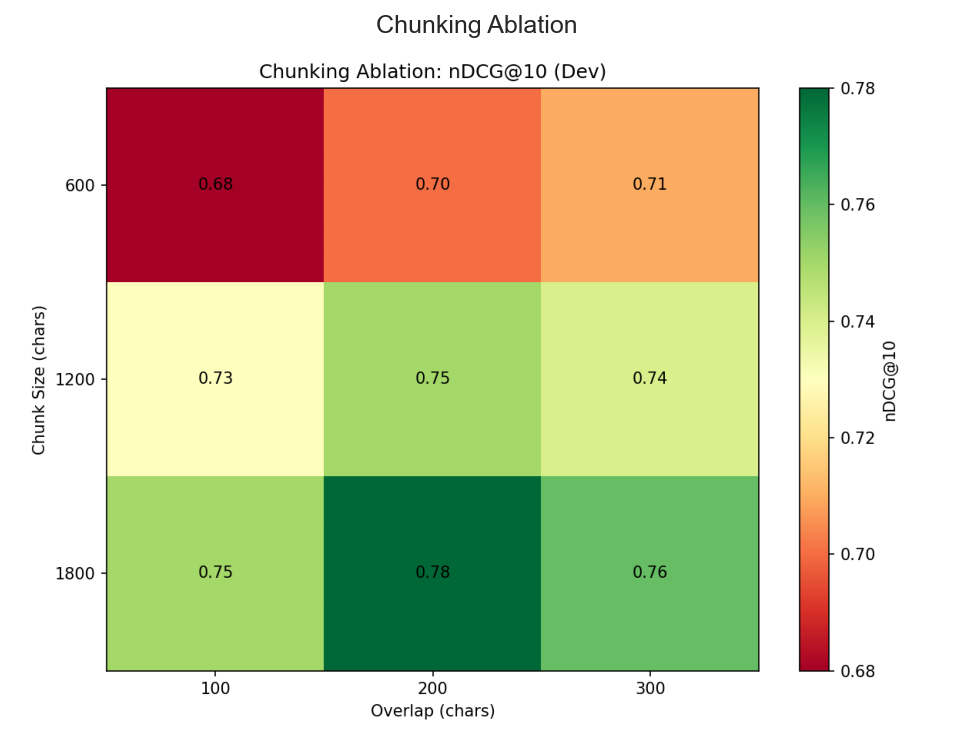

In [8]:
figs = [
    ('fig1_systems_bar.png', 'Systems Comparison'),
    ('fig2_error_budget.png', 'Error Budget by Style'),
    ('fig3_recall_vs_size.png', 'Recall@10 vs Corpus Size'),
    ('fig4_chunking_ablation.png', 'Chunking Ablation'),
]

for fname, title in figs:
    fpath = PLOTS / fname
    if fpath.exists():
        img = plt.imread(fpath)
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title)
        plt.show()
    else:
        print(f'Not found: {fname}')

## 8. Sanity Checks

In [9]:
# Oracle check
oracle_row = eval_a[eval_a['system'] == 'oracle']
if len(oracle_row) > 0:
    o = oracle_row.iloc[0]
    assert abs(o['R@1_any'] - 1.0) < 0.001, f"Oracle R@1 = {o['R@1_any']}"
    assert abs(o['nDCG@10'] - 1.0) < 0.001, f"Oracle nDCG@10 = {o['nDCG@10']}"
    print("✓ Oracle = 1.000")

# Monotonicity
for _, row in eval_a.iterrows():
    if row['system'] != 'oracle':
        assert row['R@1_any'] <= row['R@3_any'] <= row['R@5_any'] <= row['R@10_any'], f"Monotonicity failed: {row['system']}"
        assert row['MRR'] >= row['R@1_any'], f"MRR < R@1: {row['system']}"
print("✓ Monotonicity holds")

# Waterfall sums
for p in policies:
    f = EVAL / f'score_bm25_{p}.json'
    if f.exists():
        score = json.loads(f.read_text())
        wf = score.get('waterfall', {})
        total = sum(wf.get('proportions', {}).values())
        assert abs(total - 1.0) < 0.001, f"Waterfall sum = {total} for policy {p}"
print("✓ Waterfall sums = 1.000")

# Policy D violation
f = EVAL / 'score_bm25_D.json'
if f.exists():
    score = json.loads(f.read_text())
    viol = score.get('abstention', {}).get('violation_rate', 1.0)
    assert viol == 0.0, f"Policy D violation = {viol}"
    print("✓ Policy D violation = 0.000")

print("\nAll sanity checks passed!")

✓ Oracle = 1.000
✓ Monotonicity holds
✓ Waterfall sums = 1.000
✓ Policy D violation = 0.000

All sanity checks passed!
